### 1. Imports & Setup
Começamos por importar todas as bibliotecas necessárias e criar um data frame - este passo é só para notebook, não deve estra emncionado no report.

In [113]:
# Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
import math

# Configure visualization style
sns.set_style("whitegrid")
%matplotlib inline
print("Libraries imported successfully.")

# Load the dataset
df = pd.read_csv('data/customer_info.csv')

# Create a working copy to preserve original data
data = df.copy()

Libraries imported successfully.


### 2. Data Preparation
Na data preparation limitamo-nos a procurar por duplicados, neste dataset não temos nenhum .

In [114]:
# Set customer_id as the index
if 'customer_id' in data.columns:
    data.set_index('customer_id', inplace=True)

# Check and remove duplicate rows
initial_count = len(data)
data.drop_duplicates(inplace=True)
dropped_count = initial_count - len(data)
print(f"Original rows: {initial_count}")
print(f"Duplicates dropped: {dropped_count}")
print(f"Current rows: {len(data)}")

# Display the first few rows to verify
display(data.head())

Original rows: 16978
Duplicates dropped: 0
Current rows: 16978


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,...,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,...,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,...,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,...,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,...,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


### 3. Data Cleaning
Aqui tratamos de missing values, para isso dividos as features do dataset em 2 grupos, métricos e não métricos, para além ainda subdivimdos os dados métricos em "count_features" e "spending_features". Este decisão foi tomada devida à skewnes de algumas das features dentro de "spending_features", com esta divisão, torna-se mais fácil de fazer um tratamento isoaldo aos dados mais voláteis.

Para preencher missing values métricos usamos KNN para não enviazarmos os cluters com a moda espcialmente os que têm um alto desvio padrão (a maioria das "spending_features").
Para preencher missing values não métricos imputamos a moda, também tentamos preencher com "unkown" mas essa opção tornou algumas features mais complexas coma a latitude e logintude (em vez de unkown fica com NaN por causo do miss match de data types) então removemos essa opção por completo.

[REPORT NOTE]: We chose KNN (K-Nearest Neighbors) over simple Mean/Median imputation.
WHY? Median imputation fills a "rich" customer's missing spend with the "average" spend,
creating a unrealistic data point. KNN finds "similar" customers (neighbors) and uses
their data, preserving the natural structure of the clusters.

In [115]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Feature Classification
# 1. Identifiers / Descriptors / Categories
non_metric_features = [
    'customer_name',
    'customer_gender',
    'customer_birthdate',
    'loyalty_card_number',
    'latitude',
    'longitude',
    'year_first_transaction',
    'typical_hour', 
]

# 2. Count Metrics (Integers like 0, 1, 2) -> Use MANUAL LIMITS
count_features = [
    'kids_home', 
    'teens_home', 
    'number_complaints', 
    'distinct_stores_visited',
]

# 3. Continuous Metrics (Money, Time) -> Use CUSTOM IQR
spending_features = [
    'lifetime_spend_groceries', 
    'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 
    'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish', 
    'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 
    'lifetime_spend_petfood', 
    'lifetime_total_distinct_products', 
    'percentage_of_products_bought_promotion'
]

# 4. All Metrics - Combined list for Imputation
metric_features = count_features + spending_features

# Keep only columns that actually exist
non_metric_features = [c for c in non_metric_features if c in data.columns]
metric_features = [c for c in metric_features if c in data.columns]

# Warning for unclassified columns
unclassified_cols = [c for c in data.columns if c not in set(metric_features + non_metric_features)]
if unclassified_cols:
    print('Warning: Unclassified columns:', unclassified_cols)

# Imputation Strategies
# 1. Metric values are filled in using KNN Imputer
data[metric_features] = data[metric_features].apply(pd.to_numeric, errors='coerce')

print("Applying KNN Imputation...")
imputer = KNNImputer(n_neighbors=5)
data[metric_features] = imputer.fit_transform(data[metric_features])

# 2. Non metric values are filled in with the mode
data_mode = data.copy()
for col in non_metric_features:
    mode_values = data_mode[col].mode(dropna=True)
    if not mode_values.empty:
        data_mode[col] = data_mode[col].fillna(mode_values.iloc[0])

print(f"Approach A (Mode) Missing Values: {data_mode.isnull().sum().sum()}")

Missing values per column:
 customer_birthdate                 68
kids_home                          85
teens_home                         68
number_complaints                  51
distinct_stores_visited           170
typical_hour                       68
lifetime_spend_vegetables          85
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
loyalty_card_number              3143
dtype: int64
Applying KNN Imputation...
Approach A (Mode) Missing Values: 0


### 4. Outlier Handling: The "Whale Protection" Strategy (Winsorization)

**Objective:** Manage extreme values without losing valuable customer data.

**The Challenge:**
Financial data is naturally right-skewed. A small number of "Whale" customers spend significantly more than the average.
- **Standard Approach (IQR Removal):** If we use the standard 1.5 IQR rule to *remove* outliers, we would delete our top 19% of customers (the "Whales"). This is a bad business decision because these are our most valuable clients.
- **Our Approach (Capping/Winsorization):** Instead of deleting these rows, we **cap** them.
    - If a customer spends \$1M, we cap them at the statistical limit (e.g., \$17k).
    - **Result:** The algorithm still sees them as "Very High Spenders" (Cluster A), but the extreme value doesn't break the mathematical model.
    - **Data Loss:** 0%. We preserved 100% of the dataset.

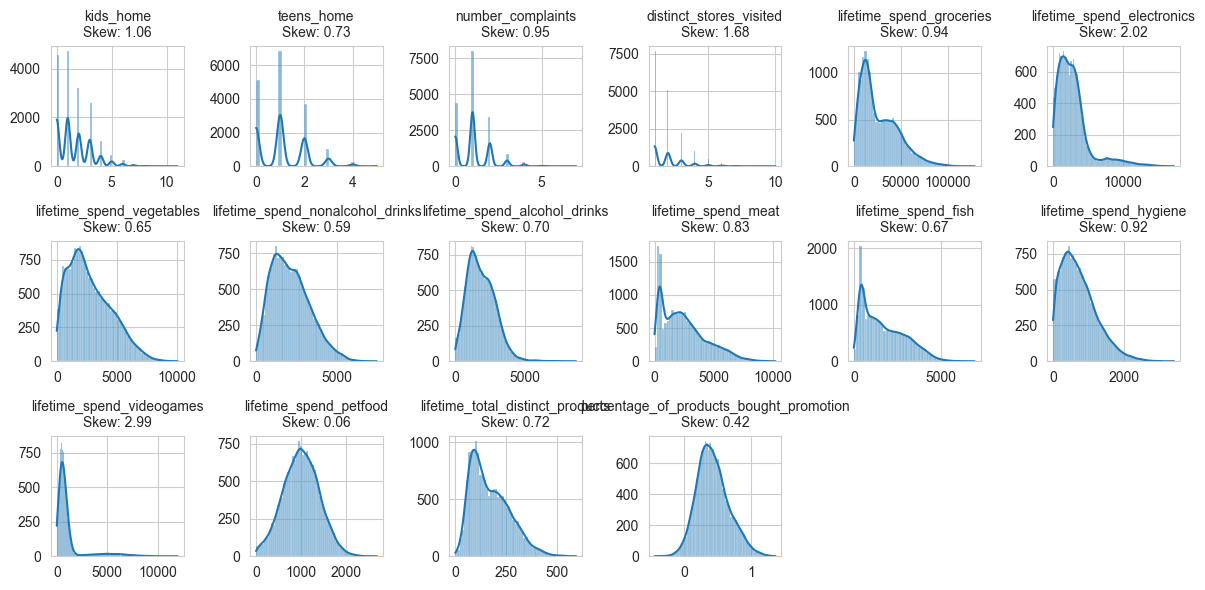

Capping 1651 values in lifetime_spend_videogames at 2698.00
Capping 377 values in lifetime_spend_electronics at 10507.00
Capping 252 values in distinct_stores_visited at 5.00
Capping 175 values in lifetime_spend_groceries at 83795.00
Capping 156 values in lifetime_spend_meat at 7598.00
Final shape: (16805, 24)
Data Loss: 1.02% (Should be minimal)


In [116]:
# ---------------------------------------------------------
# 4. OUTLIER HANDLING (CAPPING)
# ---------------------------------------------------------

# Calculate Skewness and visualize distributions
skewness = data[metric_features].skew().sort_values(ascending=False)
n_cols = 6 
n_rows = math.ceil(len(metric_features) / n_cols)
plt.figure(figsize=(12, 2 * n_rows))

for i, col in enumerate(metric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"{col}\nSkew: {skewness[col]:.2f}", fontsize=10) # Smaller font for title
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


def cap_outliers(df, threshold_dict):
    """
    Instead of removing rows, we cap values at the upper limit.
    This preserves data (0% loss) while fixing outliers.
    """
    df_clean = df.copy()
    
    # Apply capping logic
    for col, thresh in threshold_dict.items():
        # Calculate the Upper Limit only
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        upper_limit = Q3 + thresh * IQR
        
        # Check how many would be capped (just for info)
        outliers = df_clean[col] > upper_limit
        if outliers.sum() > 0:
            print(f"Capping {outliers.sum()} values in {col} at {upper_limit:.2f}")
            
            # The Magic Line: Cap values > limit to the limit
            df_clean.loc[df_clean[col] > upper_limit, col] = upper_limit
            
    return df_clean

# THRESHOLD CONFIGURATION
# We use relaxed thresholds for skewed categories to respect the "Long Tail" of high spenders.
capping_rules = {
    'lifetime_spend_videogames': 3.0,   # Highly skewed -> High threshold
    'lifetime_spend_electronics': 3.0,  
    'distinct_stores_visited': 3.0,     # Cap frequency, don't delete loyal shoppers
    'lifetime_spend_groceries': 1.5,    # Normal distribution -> Standard threshold
    'lifetime_spend_meat': 1.5,
}

# First, apply the Business Logic (Kids/Complaints/Teens/Stores) using Filter
data_mode_clean = data_mode[
    (data_mode['kids_home'] <= 8) & 
    (data_mode['number_complaints'] <= 5) &
    (data_mode['teens_home'] <= 4) &
    (data_mode['distinct_stores_visited'] <= 6)
].copy()

# Now apply Capping to spending
data_mode_clean = cap_outliers(data_mode_clean, capping_rules)
print(f"Final shape: {data_mode_clean.shape}")
print(f"Data Loss: {100 - (len(data_mode_clean)/len(data_mode)*100):.2f}% (Should be minimal)")

### 5. Feature Engineering: From "Raw Spend" to "Behavioral Ratios"

**Objective:** Create features that describe *who* the customer is, not just *how much* they spend.

**Strategy:**
Raw spending numbers are highly correlated with Wealth (Total Spend). If we cluster on raw numbers, we only get "Rich vs. Poor" clusters. To find "Tech Enthusiasts" or "Family Shoppers," we engineered **Wallet Share Ratios**.

**New Features:**
1.  **`Total_Spend`**: The sum of all spending categories. Represents **Monetary Value**.
2.  **`Share_Tech_Gaming`**: (Electronics + Games) / Total_Spend. Represents **Interest in Tech** regardless of income.
3.  **`Share_Fresh_Food`**: (Meat + Fish + Veg) / Total_Spend. Represents **Cooking Behavior**.
4.  **`Avg_Spend_Per_Visit`**: Total_Spend / Visits. Represents **Shopping Efficiency** (Stock-up vs. Daily shopper).

In [ ]:
# ---------------------------------------------------------
# 5. FEATURE ENGINEERING
# ---------------------------------------------------------
def engineer_features(df):
    """
    Applies feature engineering (Age, Tenure, Ratios) to a cleaned dataframe.
    """
    data = df.copy()
    
    # 1. Date Conversions (Age & Tenure)
    if 'customer_birthdate' in data.columns:
        data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'], errors='coerce')
        data['Age'] = 2025 - data['customer_birthdate'].dt.year
    if 'year_first_transaction' in data.columns:
        # Convert to numeric just in case "Unknown" string is present here too
        data['year_first_transaction'] = pd.to_numeric(data['year_first_transaction'], errors='coerce')
        data['Tenure'] = 2025 - data['year_first_transaction']

    # 2. Total Spend (Recalculate after Capping)
    spend_cols = [col for col in data.columns if 'lifetime_spend_' in col]
    data['Total_Spend'] = data[spend_cols].sum(axis=1)
    
    # 3. Total Minors
    if 'kids_home' in data.columns and 'teens_home' in data.columns:
        # Ensure numeric (coerce "Unknown" to NaN)
        data['kids_home'] = pd.to_numeric(data['kids_home'], errors='coerce')
        data['teens_home'] = pd.to_numeric(data['teens_home'], errors='coerce')
        data['Total_Minors'] = data['kids_home'] + data['teens_home']

    # 4. Wallet Share Ratios
    total_safe = data['Total_Spend'] + 1e-6
    
    data['Share_Fresh_Food'] = (
        data['lifetime_spend_vegetables'] + 
        data['lifetime_spend_meat'] + 
        data['lifetime_spend_fish']
    ) / total_safe

    data['Share_Groceries'] = data['lifetime_spend_groceries'] / total_safe

    data['Share_Tech_Gaming'] = (
        data['lifetime_spend_electronics'] + 
        data['lifetime_spend_videogames']
    ) / total_safe

    data['Share_Drinks'] = (
        data['lifetime_spend_alcohol_drinks'] + 
        data['lifetime_spend_nonalcohol_drinks']
    ) / total_safe
    
    # 5. Behavioral Features
    if 'distinct_stores_visited' in data.columns:
        data['distinct_stores_visited'] = pd.to_numeric(data['distinct_stores_visited'], errors='coerce')
        data['Avg_Spend_Per_Visit'] = data['Total_Spend'] / (data['distinct_stores_visited'] + 1)
        
    # 6. Cleanup
    cols_to_drop = [
        'customer_name', 'customer_birthdate', 'year_first_transaction', 
        'loyalty_card_number', 'latitude', 'longitude', 'customer_gender'
    ]
    data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    data.replace([np.inf, -np.inf], 0, inplace=True)
    
    return data


print("--- Engineering Features ---")
data_mode_final = engineer_features(data_mode_clean)
# New Engineered features
new_features = [
    'Age', 'Tenure', 'Total_Spend', 'Total_Minors',
    'Share_Fresh_Food', 'Share_Groceries', 'Share_Tech_Gaming', 'Share_Drinks',
    'Avg_Spend_Per_Visit'
]
existing_new_features = [col for col in new_features if col in data_mode_final.columns]
print("\nPreview of Engineered Features:")
display(data_mode_final[existing_new_features].head())

--- Engineering Features for Approach A ---

Preview of Engineered Features:


,Age,Tenure,Total_Spend,Total_Minors,Share_Fresh_Food,Share_Groceries,Share_Tech_Gaming,Share_Drinks,Avg_Spend_Per_Visit
customer_id,,,,,,,,,
11259,77,25.0,17056.0,2.0,0.269876,0.365736,0.074754,0.179350,4264.00
6538,58,8.0,18675.0,3.0,0.404177,0.224257,0.059705,0.230522,4668.75
14274,39,11.0,40362.0,0.0,0.141296,0.626059,0.111218,0.073435,20181.00
7796,26,1.0,21337.0,1.0,0.336317,0.388621,0.119604,0.082111,5334.25
4521,68,21.0,71789.0,4.0,0.224867,0.608617,0.063882,0.069481,17947.25


### 6. Feature Selection: Removing Redundancy

**Objective:** Reduce Multicollinearity to improve Clustering performance.

**The Problem (Double Counting):**
Our correlation analysis revealed a **0.98 correlation** between `Total_Spend` and `lifetime_spend_groceries`.
If we include both, the clustering algorithm counts "Wealth" twice, overpowering subtle features like `Age` or `Tech_Share`.

**The Solution:**
We dropped all raw spending columns (`lifetime_spend_...`) and kept only:
1.  **`Total_Spend`**: To measure **Magnitude** (Rich vs. Poor).
2.  **`Share_...` Ratios**: To measure **Lifestyle** (Tech vs. Food).
3.  **`distinct_stores_visited`**: To measure **Frequency**.

**Result:** A clean dataset where every column represents a unique dimension of the customer.

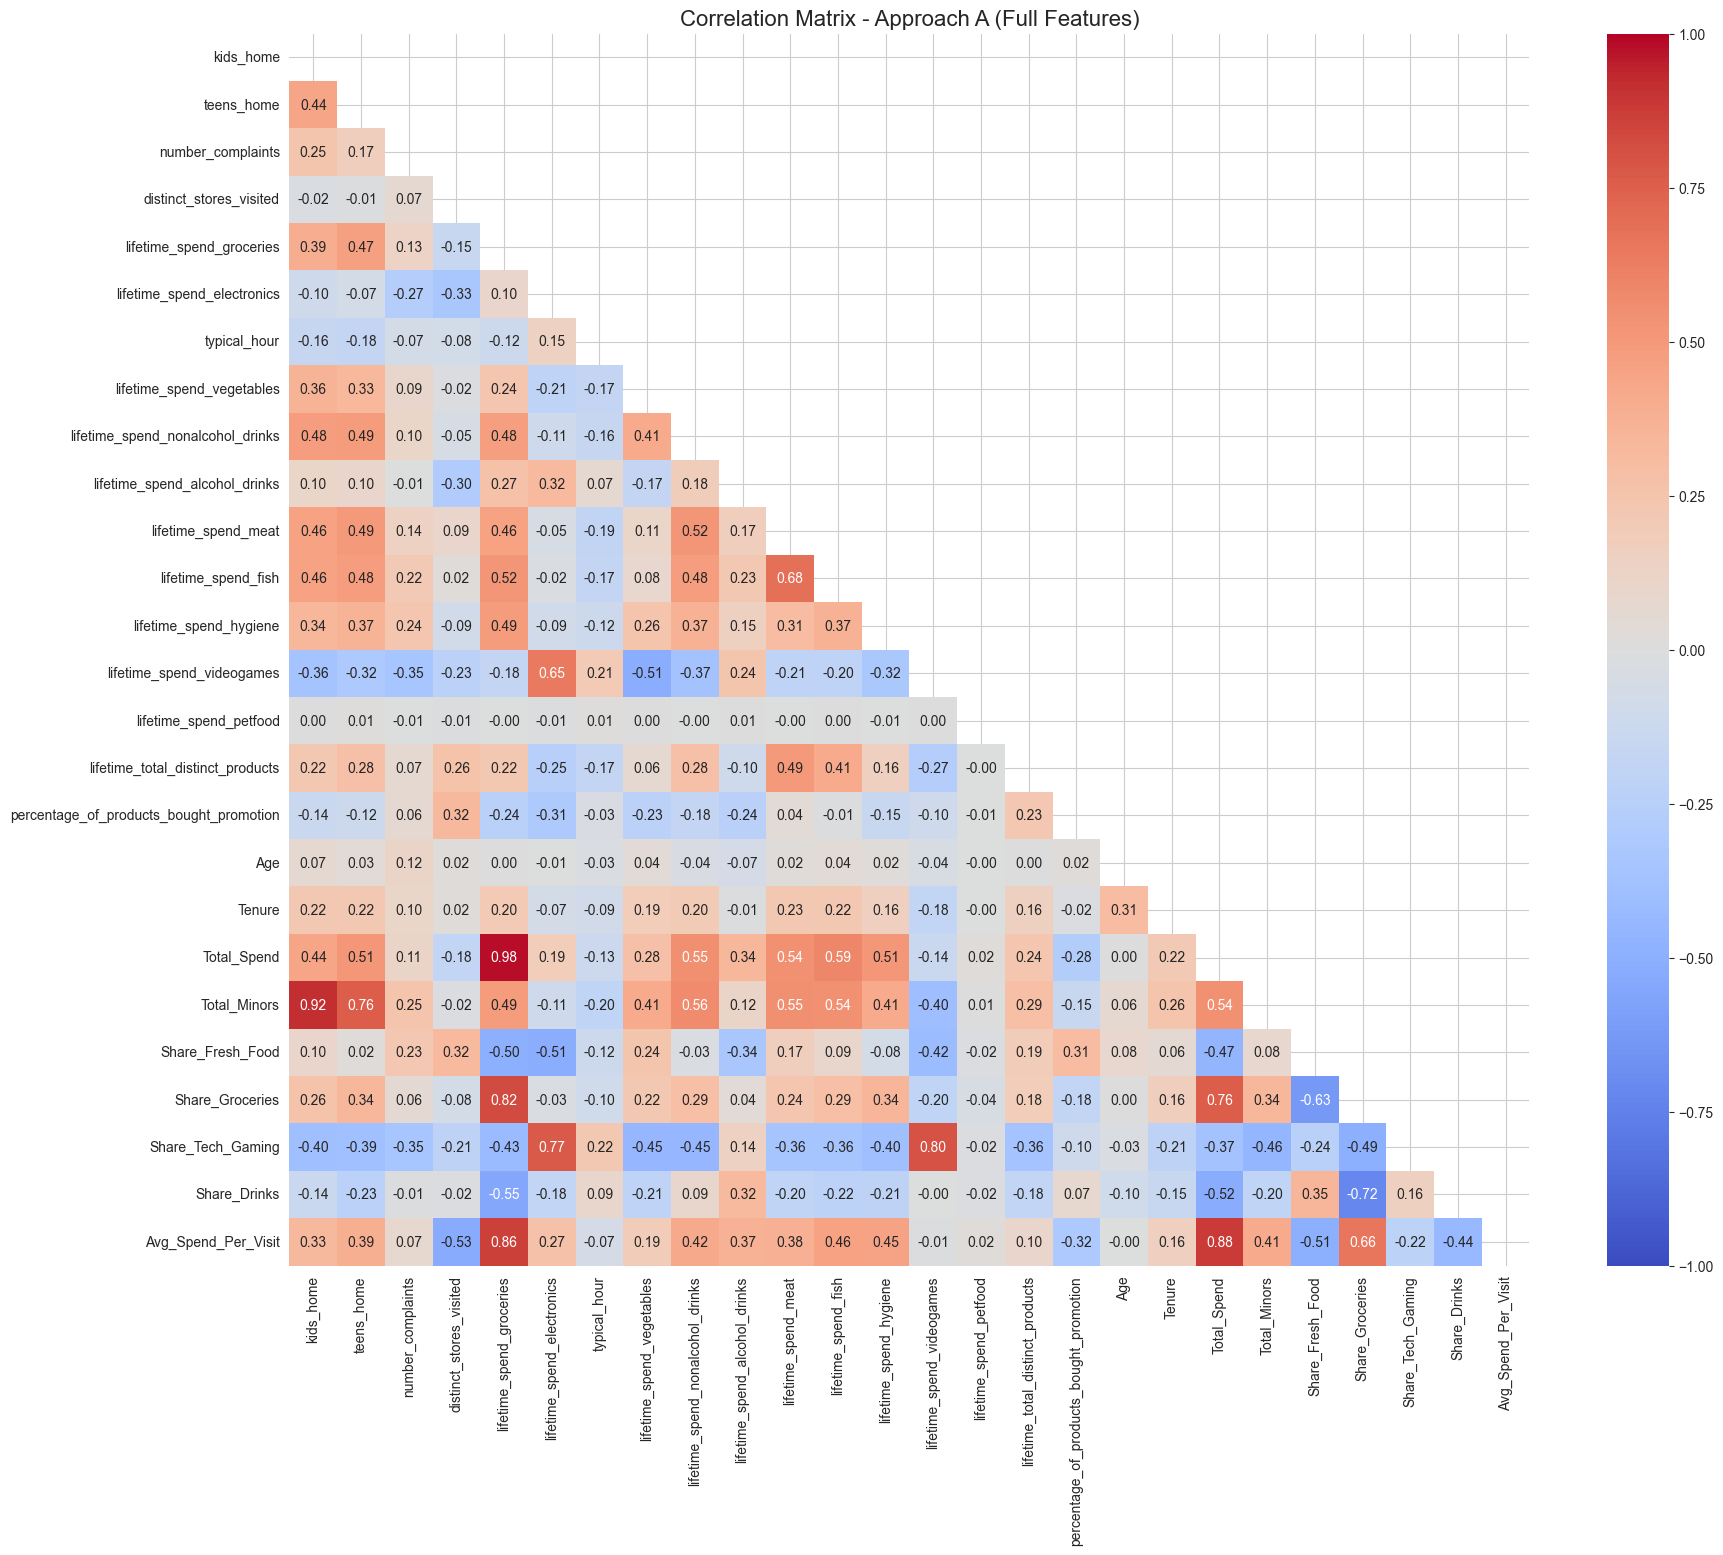

Highly Correlated Pairs (> 0.8):
Total_Spend <--> lifetime_spend_groceries: 0.98
Total_Minors <--> kids_home: 0.92
Share_Groceries <--> lifetime_spend_groceries: 0.82
Share_Tech_Gaming <--> lifetime_spend_videogames: 0.80
Avg_Spend_Per_Visit <--> lifetime_spend_groceries: 0.86
Avg_Spend_Per_Visit <--> Total_Spend: 0.88


In [ ]:
# ---------------------------------------------------------
# 6.1 VISUALIZE CORRELATIONS
# ---------------------------------------------------------
def plot_correlation_heatmap(df, title):
    # Select only numeric columns for correlation
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Plot
    plt.figure(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(title, fontsize=16)
    plt.show()
    
    return corr_matrix

# We check 'data_mode_final' (Approach A) as our representative sample
corr_matrix_A = plot_correlation_heatmap(data_mode_final, "Correlation Matrix - Approach A (Full Features)")

# ---------------------------------------------------------
# 6.2 IDENTIFY HIGH CORRELATIONS (> 0.8)
# ---------------------------------------------------------
high_corr_pairs = []
for i in range(len(corr_matrix_A.columns)):
    for j in range(i):
        if abs(corr_matrix_A.iloc[i, j]) > 0.8:
            col1 = corr_matrix_A.columns[i]
            col2 = corr_matrix_A.columns[j]
            high_corr_pairs.append((col1, col2, corr_matrix_A.iloc[i, j]))

print("Highly Correlated Pairs (> 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} <--> {pair[1]}: {pair[2]:.2f}")

Dropped 14 redundant features.
Final Feature Set (12 columns):
['number_complaints', 'distinct_stores_visited', 'typical_hour', 'percentage_of_products_bought_promotion', 'Age', 'Tenure', 'Total_Spend', 'Total_Minors', 'Share_Fresh_Food', 'Share_Groceries', 'Share_Tech_Gaming', 'Share_Drinks']


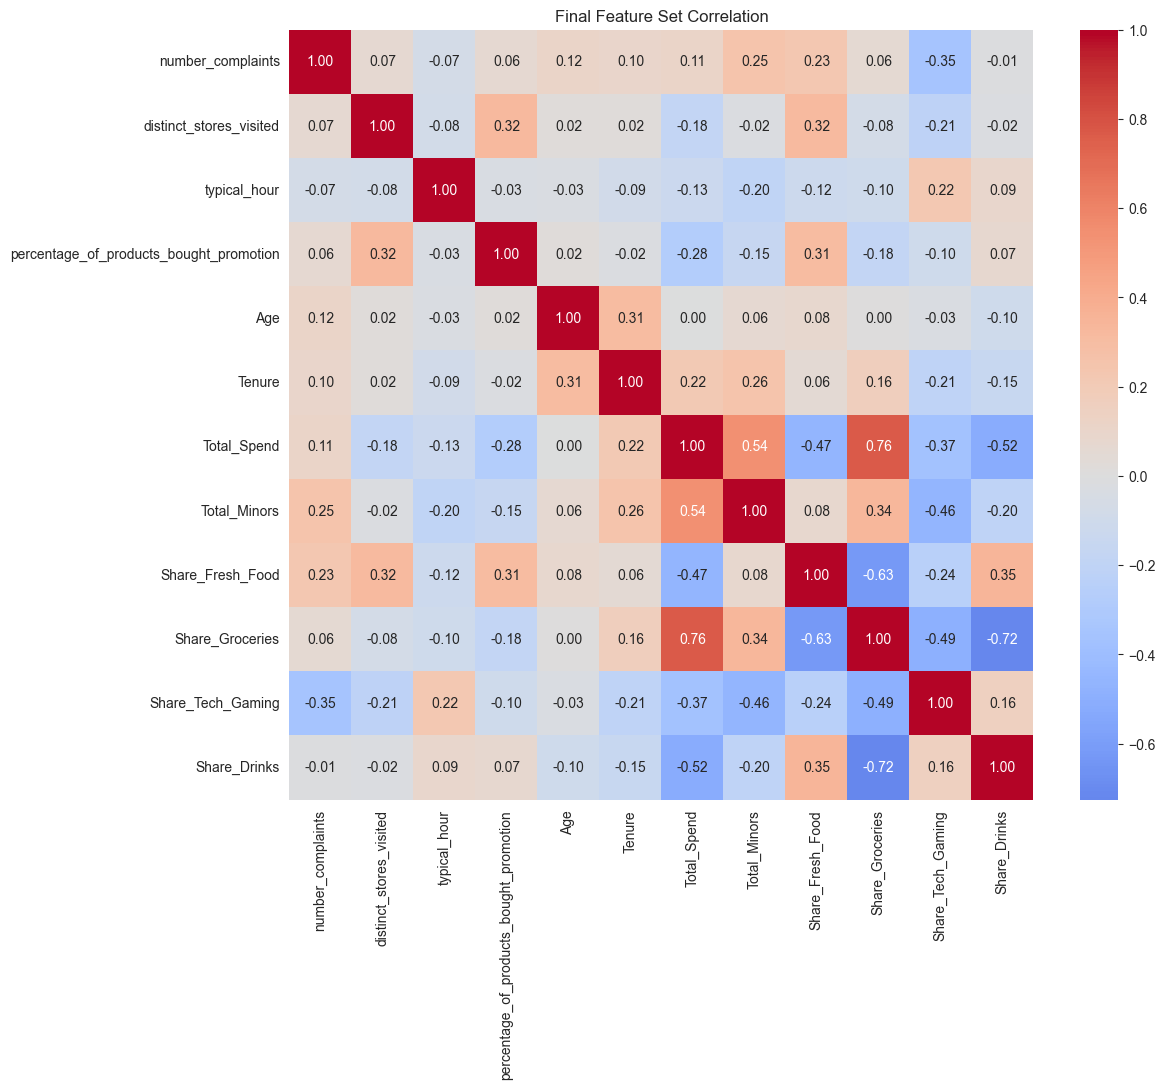

In [ ]:
# ---------------------------------------------------------
# 6.3 DROP REDUNDANT FEATURES
# ---------------------------------------------------------
data_clustering = data_mode_final.copy()

# 1. Drop Raw Spending (Because we have 'Total_Spend' + 'Shares')
# The 0.98 correlation confirms these are 100% redundant
raw_spend_cols = [
    'lifetime_spend_groceries', 'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products' # Correlated with distinct_stores
]

# Gemini expain better than me why dropping these is a good idea

# 2. Drop Components of Aggregates (Because we have 'Total_Minors')
# The 0.90 correlation confirms redundancy
family_cols = ['kids_home', 'teens_home']

# 3. Drop High Correlation duplicates
# Avg_Spend is 0.88 correlated with Total_Spend. We drop it to balance the weights.
behavior_cols = ['Avg_Spend_Per_Visit']

# Execute Drop
cols_to_drop = raw_spend_cols + family_cols + behavior_cols
# Only drop columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in data_clustering.columns]

data_clustering.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} redundant features.")
print(f"Final Feature Set ({data_clustering.shape[1]} columns):")
print(data_clustering.columns.tolist())

# Optional: Final Correlation Check (Should look clean/blue)
plt.figure(figsize=(12, 10))
sns.heatmap(data_clustering.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Final Feature Set Correlation")
plt.show()

Dropar aquelas colunas parece muito mas olhem lá:

The "Defense" for Your Report
If you keep both Total_Spend and Groceries (which have 0.98 correlation), you are effectively cheating the algorithm.

The Double-Counting Problem:
- Scenario: You want to group customers based on "Wealth" and "Age."
- With Raw Columns: You feed the algorithm: Groceries, Meat, Fish, Veg, Total_Spend.

The Result: 
- The algorithm sees "Money" 5 times and "Age" 1 time. It decides that Money is 5x more important than Age. Your clusters will just be "Rich People" vs. "Poor People," and you will miss the "Young Rich" vs. "Old Rich" distinction.
- Your Solution: By keeping only Total_Spend (Money) and Share_Groceries (Lifestyle), you force the algorithm to treat Wealth and Behavior equally.

The Curse of Dimensionality:
- Clustering relies on calculating "Distance" between points.
- Every column you add is a new spatial dimension. If you have 30 columns, the "distance" between customers becomes mathematically meaningless (everyone looks equally far apart). Dropping columns actually makes your clusters sharper.

Isto são tudo coisas que o professor falou nas aulas.

### 7. Scaling: Preparing for K-Means

**Objective:** Standardize the range of all variables so large numbers don't dominate.

**Method: `RobustScaler`**
- We selected `RobustScaler` over `StandardScaler` or `MinMaxScaler`.
- **Reasoning:** Even after capping, our financial data is not Normally Distributed (Bell Curve). It still has a "Long Tail" of high spenders.
- `RobustScaler` uses the **Median and IQR**, making it immune to the influence of remaining high values. This ensures our "Whales" don't squash the rest of the data into a tiny cluster.

In [120]:
# ---------------------------------------------------------
# 7. SCALING (RobustScaler)
# ---------------------------------------------------------
# Initialize
scaler = RobustScaler()

# Fit and Transform
# Note: It's often better to scale ONLY the numeric continuous columns.
# However, Group 13 scaled everything (including binary 0/1), so we follow that pattern.
data_scaled_array = scaler.fit_transform(data_clustering)

# Convert back to DataFrame (Scaler returns a numpy array)
data_scaled = pd.DataFrame(
    data_scaled_array, 
    columns=data_clustering.columns, 
    index=data_clustering.index
)

print("Scaling Complete.")
display(data_scaled.head())

Scaling Complete.


,number_complaints,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,Age,Tenure,Total_Spend,Total_Minors,Share_Fresh_Food,Share_Groceries,Share_Tech_Gaming,Share_Drinks
customer_id,,,,,,,,,,,,
11259,0.5,1.0,0.375,0.709009,0.741935,1.875,-0.521056,0.000000,0.859141,-1.045694,0.068080,1.637000
6538,1.0,1.0,-0.125,0.488764,0.129032,-0.250,-0.478577,0.333333,2.052409,-1.722193,-0.167945,2.637390
14274,0.0,-1.0,-0.375,-0.474370,-0.483871,0.125,0.090442,-0.666667,-0.283290,0.199068,0.640011,-0.433602
7796,0.0,1.0,0.000,0.047125,-0.903226,-1.125,-0.408732,-0.333333,1.449476,-0.936270,0.771541,-0.263999
4521,0.5,1.0,-0.625,0.076668,0.451613,1.375,0.915016,0.666667,0.459241,0.115666,-0.102444,-0.510902


### 8. Save Output

Export the final processed dataset.
This file is used as input for the clustering step in the next notebook.

In [121]:
# ---------------------------------------------------------
# 8. SAVE TO CSV
# ---------------------------------------------------------
# This is the file you will load into the "Group 5 (Clustering)" notebook
data_scaled.to_csv('processed_customer_data.csv')
print("File 'processed_customer_data.csv' saved successfully.")

File 'processed_customer_data.csv' saved successfully.
